# Quantum Dot – Cavity QED Simulation
### Jaynes–Cummings model with Lindblad dissipation · QuTiP

---

This notebook simulates an **InAs/GaAs self-assembled quantum dot (QD) embedded in a
photonic-crystal nanocavity**, modelled as a two-level emitter (TLS) strongly coupled
to a single quantised cavity mode.  The system is treated as an **open quantum system**:
coherent Jaynes–Cummings dynamics plus incoherent Lindblad dissipation.

Five physical observables are computed and plotted:
1. **Vacuum Rabi spectrum** — steady-state transmission showing the doublet
2. **Vacuum Rabi oscillations** — time-domain coherent energy exchange
3. **Wigner function** — phase-space quasi-probability of the cavity field
4. **Photon statistics / photon blockade** — $g^{(2)}(0)$ and $P(n)$
5. **Polariton dispersion** — eigenvalue avoided crossing

> **Convention:** $\hbar = 1$ throughout.  All frequencies are angular, in units of $2\pi \times \text{GHz}$.


## 1. Imports


In [1]:
# =============================================================================
# IMPORTS
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import math
import warnings
warnings.filterwarnings('ignore')

import qutip as qt
from qutip import mesolve, basis, tensor, destroy, qeye, sigmaz, sigmam, sigmap

print(f"QuTiP  : {qt.__version__}")
print(f"NumPy  : {np.__version__}")


QuTiP  : 5.2.3
NumPy  : 2.0.1


## 2. System Parameters

### Physical system

An InAs/GaAs QD in a photonic-crystal nanocavity is modelled as a **two-level system (TLS)**
coupled to a single cavity mode.  The relevant energy and rate scales are:

| Symbol | Meaning | Value |
|--------|---------|-------|
| $g$ | Vacuum Rabi coupling | $2\pi \times 100\ \text{MHz}$ |
| $\kappa$ | Cavity photon decay rate | $2\pi \times 10\ \text{MHz}$ |
| $\gamma$ | QD spontaneous emission (non-cavity) | $2\pi \times 5\ \text{MHz}$ |
| $\gamma_\phi$ | Pure dephasing (LA-phonon) | $2\pi \times 2\ \text{MHz}$ |

### Vacuum Rabi coupling

The coupling $g$ is set by the overlap of the QD dipole moment $\mathbf{d}$ with the
cavity vacuum electric field $\mathbf{E}_\text{vac}$:

$$g = \frac{\mathbf{d} \cdot \mathbf{E}_\text{vac}}{\hbar}, \qquad
E_\text{vac} = \sqrt{\frac{\hbar\omega_c}{2\varepsilon_0 V_\text{eff}}}$$

where $V_\text{eff}$ is the effective mode volume of the cavity.  Smaller $V_\text{eff}$
gives larger $g$ — the key motivation for photonic-crystal cavities with
$V_\text{eff} \sim (\lambda/n)^3$.

### Figures of merit

**Cooperativity:**

$$C = \frac{4g^2}{\kappa\gamma} \gg 1$$

$C$ is proportional to the probability that a cavity photon is re-absorbed by the QD
before leaking out.  $C = 800$ here — deep strong coupling.

**Strong-coupling criterion:**

$$g > \frac{\kappa + \gamma}{2}$$

The ratio $g / [(\kappa+\gamma)/2]$ must exceed 1 for the vacuum Rabi doublet to be
spectrally resolved above the combined linewidth.

### Fock space truncation

The cavity mode is an infinite-dimensional harmonic oscillator.  We truncate at
`N_PHOTONS = 20`, justified because the driven steady state occupies $\langle n \rangle \ll 1$
photon in the strong-coupling regime; $P(n = 20) \approx 0$ in every calculation.


In [2]:
# =============================================================================
# SYSTEM PARAMETERS
# =============================================================================
# Physical system: InAs/GaAs self-assembled QD in a photonic-crystal nanocavity.
# All frequencies are angular (rad/s equivalent), scaled to GHz units (×2π).
# Setting ħ = 1 throughout.

# --- Fock space truncation ---------------------------------------------------
# The cavity mode is an infinite-dimensional harmonic oscillator; we truncate at
# N_PHOTONS.  Chosen large enough so that P(n = N_PHOTONS) ≈ 0 in every run.
N_PHOTONS = 20

# --- Bare frequencies --------------------------------------------------------
# Both are set equal → perfect resonance (δ = ω_c − ω_q = 0).
# In GHz units: 1.0 GHz is the reference; only ratios matter.
omega_c = 2 * np.pi * 1.0    # Cavity resonance frequency  [rad × GHz]
omega_q = 2 * np.pi * 1.0    # QD transition frequency     [rad × GHz]

# --- Coupling and dissipation rates ------------------------------------------
# g     : vacuum Rabi coupling.  Sets the coherent exchange rate between the
#         cavity field and the QD dipole.  g ∝ d·E_vac where d is the QD
#         dipole moment and E_vac = sqrt(ħω/2ε₀V) is the vacuum field per photon.
# kappa : cavity field decay rate (1/photon lifetime).  Related to quality
#         factor by κ = ω_c / Q.
# gamma : QD spontaneous emission rate into all modes (non-cavity leakage).
# gamma_phi : pure dephasing — destroys off-diagonal coherences without
#         changing populations.  Dominant source: LA-phonon scattering in III–V.
g         = 2 * np.pi * 0.10    # Vacuum Rabi coupling      ~100 MHz
kappa     = 2 * np.pi * 0.01    # Cavity photon decay        ~10  MHz
gamma     = 2 * np.pi * 0.005   # QD spontaneous emission     ~5  MHz
gamma_phi = 2 * np.pi * 0.002   # Pure dephasing              ~2  MHz

# --- Figures of merit --------------------------------------------------------
# Cooperativity C = 4g² / (κγ).
#   C ≫ 1 means the cavity-mediated emission (Purcell effect) dominates over
#   free-space emission.  C ~ g²/κγ is the probability of re-absorption before loss.
cooperativity = 4 * g**2 / (kappa * gamma)

# Strong-coupling criterion: g > (κ + γ)/2
#   The coupling_ratio must exceed 1 for the vacuum Rabi doublet to be resolved.
coupling_ratio = g / ((kappa + gamma) / 2)

print(f"{'='*50}")
print(f"  g / 2π          = {g/(2*np.pi)*1000:.0f} MHz")
print(f"  κ / 2π          = {kappa/(2*np.pi)*1000:.0f} MHz")
print(f"  γ / 2π          = {gamma/(2*np.pi)*1000:.1f} MHz")
print(f"  γφ / 2π         = {gamma_phi/(2*np.pi)*1000:.1f} MHz")
print(f"  Cooperativity C = {cooperativity:.0f}")
print(f"  g / ((κ+γ)/2)   = {coupling_ratio:.1f}")
print(f"  Strong coupling : {'YES ✓' if coupling_ratio > 1 else 'NO ✗'}")
print(f"{'='*50}")


  g / 2π          = 100 MHz
  κ / 2π          = 10 MHz
  γ / 2π          = 5.0 MHz
  γφ / 2π         = 2.0 MHz
  Cooperativity C = 800
  g / ((κ+γ)/2)   = 13.3
  Strong coupling : YES ✓


## 3. Composite Hilbert Space and Operators

### Structure of the Hilbert space

The total Hilbert space is the **tensor product** of the cavity and QD subspaces:

$$\mathcal{H} = \mathcal{H}_\text{cav} \otimes \mathcal{H}_\text{QD}, \qquad
\dim(\mathcal{H}) = N_\text{photons} \times 2 = 40$$

**Cavity** — harmonic oscillator truncated to $N_\text{photons}$ Fock states $\{|0\rangle, |1\rangle, \ldots, |N-1\rangle\}$:

$$\hat{a}|n\rangle = \sqrt{n}\,|n-1\rangle, \qquad
\hat{a}^\dagger|n\rangle = \sqrt{n+1}\,|n+1\rangle, \qquad
\hat{n} = \hat{a}^\dagger\hat{a}$$

**QD** — two-level system with basis $|e\rangle = (1,0)^T$ (excited) and $|g\rangle = (0,1)^T$ (ground):

$$\hat{\sigma}^- = |g\rangle\langle e| = \begin{pmatrix}0&0\\1&0\end{pmatrix}, \quad
\hat{\sigma}^+ = |e\rangle\langle g| = \begin{pmatrix}0&1\\0&0\end{pmatrix}, \quad
\hat{\sigma}_z = |e\rangle\langle e| - |g\rangle\langle g| = \begin{pmatrix}1&0\\0&-1\end{pmatrix}$$

### Tensor-product embedding

An operator $\hat{O}_c$ acting on the cavity is embedded in the composite space as
$\hat{O}_c \otimes \hat{I}_\text{QD}$, and an operator $\hat{O}_q$ acting on the QD
as $\hat{I}_\text{cav} \otimes \hat{O}_q$.  QuTiP's `tensor(A, B)` computes the
Kronecker product $A \otimes B$.

For a composite basis state $|n, s\rangle = |n\rangle_c \otimes |s\rangle_q$, operators act as:

$$\hat{a}\,|n,s\rangle = \sqrt{n}\,|n-1,s\rangle, \qquad
\hat{\sigma}^-|n,s\rangle = \delta_{s,e}\,|n,g\rangle$$


In [3]:
# =============================================================================
# COMPOSITE HILBERT SPACE AND OPERATORS
# =============================================================================
# Total space: H = H_cav ⊗ H_QD   (dim = N_PHOTONS × 2)
#
# Cavity subsystem (harmonic oscillator, Fock basis |n⟩):
#   a_cav   : annihilation operator, a|n⟩ = √n |n−1⟩
#   a†_cav  : creation operator,    a†|n⟩ = √(n+1)|n+1⟩
#   n_hat   : number operator,      n̂|n⟩ = n|n⟩
#
# QD subsystem (two-level system, basis |e⟩ = (1,0)ᵀ, |g⟩ = (0,1)ᵀ):
#   sm_qd   : σ⁻ = |g⟩⟨e|  (lowers excitation)
#   sp_qd   : σ⁺ = |e⟩⟨g|  (raises excitation)
#   sz_qd   : σz = |e⟩⟨e| − |g⟩⟨g|  (inversion)
#
# Embedding into the composite space via tensor product:
#   Cavity operator O_c acts as: O_c ⊗ I_QD
#   QD operator O_q acts as:     I_cav ⊗ O_q
# QuTiP's tensor(A, B) forms the Kronecker product A ⊗ B.

# Cavity operators in their own Fock space
a_cav = destroy(N_PHOTONS)

# QD operators in their own 2D Hilbert space
sm_qd = sigmam()    # σ⁻: |g⟩⟨e|
sp_qd = sigmap()    # σ⁺: |e⟩⟨g|
sz_qd = sigmaz()    # σz: |e⟩⟨e| − |g⟩⟨g|

# Composite-space operators (N_PHOTONS×2 dimensional)
a  = tensor(a_cav,          qeye(2))          # cavity annihilation
sm = tensor(qeye(N_PHOTONS), sm_qd)           # QD lowering
sp = tensor(qeye(N_PHOTONS), sp_qd)           # QD raising
sz = tensor(qeye(N_PHOTONS), sz_qd)           # QD inversion

print(f"Composite Hilbert space dimension : {a.shape[0]}")
print(f"  = N_PHOTONS × 2 = {N_PHOTONS} × 2 = {N_PHOTONS*2}")
print(f"Operator dims (QuTiP): {a.dims}")
print(f"H is Hermitian check (will verify after build): will check below")


Composite Hilbert space dimension : 40
  = N_PHOTONS × 2 = 20 × 2 = 40
Operator dims (QuTiP): [[20, 2], [20, 2]]
H is Hermitian check (will verify after build): will check below


## 4. Jaynes–Cummings Hamiltonian and Lindblad Master Equation

### Jaynes–Cummings Hamiltonian

The system is described by the **Jaynes–Cummings (JC) model** — the exactly solvable
quantum-optical model of a TLS coupled to a single quantised field mode ($\hbar = 1$):

$$\hat{H} = \underbrace{\omega_c\,\hat{a}^\dagger\hat{a}}_{\text{cavity}} +
             \underbrace{\omega_q\,\hat{\sigma}^+\hat{\sigma}^-}_{\text{QD}} +
             \underbrace{g\left(\hat{a}^\dagger\hat{\sigma}^- + \hat{a}\hat{\sigma}^+\right)}_{\text{JC coupling}}$$

**Term 1** — $\omega_c\hat{a}^\dagger\hat{a}$: counts the cavity photon number and
assigns energy $\omega_c$ per photon.

**Term 2** — $\omega_q\hat{\sigma}^+\hat{\sigma}^-= \omega_q|e\rangle\langle e|$:
assigns energy $\omega_q$ to the excited state.

**Term 3** — $g(\hat{a}^\dagger\hat{\sigma}^- + \hat{a}\hat{\sigma}^+)$: the
**rotating-wave approximation (RWA)** form of the light–matter coupling.
$\hat{a}^\dagger\hat{\sigma}^-$ destroys a QD excitation and creates a cavity photon;
$\hat{a}\hat{\sigma}^+$ is the reverse.  Counter-rotating terms ($\hat{a}^\dagger\hat{\sigma}^+$,
$\hat{a}\hat{\sigma}^-$) are dropped as they are off-resonant by $\sim 2\omega_c$.

The JC interaction **conserves the total excitation number** $\hat{N} = \hat{a}^\dagger\hat{a} + \hat{\sigma}^+\hat{\sigma}^-$,
so $H$ is block-diagonal in $\hat{N}$ and the $N$-excitation sectors decouple.

### Lindblad master equation

Real devices have dissipation.  The **Lindblad master equation** describes the
Markovian (memoryless) evolution of the density matrix $\hat{\rho}$:

$$\frac{d\hat{\rho}}{dt} = -i[\hat{H},\hat{\rho}] + \sum_k \mathcal{D}[\hat{L}_k]\hat{\rho}$$

where the **dissipator** for each collapse operator $\hat{L}_k$ is:

$$\mathcal{D}[\hat{L}]\hat{\rho} = \hat{L}\hat{\rho}\hat{L}^\dagger - \tfrac{1}{2}\hat{L}^\dagger\hat{L}\hat{\rho} - \tfrac{1}{2}\hat{\rho}\hat{L}^\dagger\hat{L}$$

The $\hat{L}\hat{\rho}\hat{L}^\dagger$ term performs a **quantum jump** (population
transfer); the anti-commutator terms provide the associated **decoherence** of
off-diagonal elements.

### The three dissipation channels

| Collapse operator $\hat{L}_k$ | Rate | Physical mechanism |
|-------------------------------|------|--------------------|
| $\sqrt{\kappa}\,\hat{a}$ | $\kappa$ | Cavity photon leakage through mirrors or into radiation modes |
| $\sqrt{\gamma}\,\hat{\sigma}^-$ | $\gamma$ | QD spontaneous emission into non-cavity modes |
| $\sqrt{\gamma_\phi}\,\hat{\sigma}_z$ | $\gamma_\phi$ | Pure dephasing: LA-phonon scattering in the semiconductor host |

**Pure dephasing** via $\hat{\sigma}_z$ is special: the jump $\hat{\sigma}_z\hat{\rho}\hat{\sigma}_z$
flips the sign of the coherence $\rho_{eg}$ with each scattering event, washing out
phase relationships without changing $\rho_{ee}$ or $\rho_{gg}$.


In [4]:
# =============================================================================
# JAYNES–CUMMINGS HAMILTONIAN AND LINDBLAD COLLAPSE OPERATORS
# =============================================================================
#
# Jaynes–Cummings Hamiltonian (ħ = 1):
#
#   H = ω_c a†a  +  ω_q σ⁺σ⁻  +  g(a†σ⁻ + aσ⁺)
#       ────────    ──────────    ──────────────────
#       [1]         [2]           [3]
#
#   [1] Cavity:    ω_c a†a counts the photon number n̂ and assigns energy ω_c per photon.
#   [2] QD:        ω_q σ⁺σ⁻ = ω_q |e⟩⟨e| — energy of the excited state.
#   [3] Coupling:  a†σ⁻ destroys a QD excitation and creates a cavity photon (absorption
#                  of QD photon into cavity field); aσ⁺ is the reverse (emission).
#                  This is the rotating-wave approximation (RWA) — counter-rotating terms
#                  a†σ⁺ and aσ⁻ are dropped because they are off-resonant by ~2ω_c.
#
# The JC interaction conserves the total excitation number N̂ = a†a + σ⁺σ⁻,
# so the Hamiltonian is block-diagonal in N̂ — each N-excitation sector can be
# solved independently.

H = (  omega_c * a.dag() * a       # [1] cavity energy
     + omega_q * sp * sm            # [2] QD energy
     + g * (a.dag() * sm + a * sp)  # [3] JC coupling (RWA)
    )

print(f"H shape    : {H.shape}")
print(f"H Hermitian: {H.isherm}")

# =============================================================================
# LINDBLAD COLLAPSE OPERATORS
# =============================================================================
# The Lindblad master equation:
#
#   dρ/dt = −i[H, ρ] + Σ_k [ L_k ρ L_k† − ½{L_k†L_k, ρ} ]
#
# Each collapse operator L_k describes one incoherent channel.
# The dissipator D[L]ρ = LρL† − ½L†Lρ − ½ρL†L generates:
#   - LρL†    : quantum jump (population transfer)
#   - −½{L†L,ρ}: dephasing of off-diagonal elements (decoherence)
#
# Channel 0 — Cavity decay (√κ · a):
#   Describes photon leakage through the cavity mirrors.
#   Jump: a|n⟩⟨n|a† = n |n−1⟩⟨n−1| → reduces photon number by 1.
#   Rate: κ [GHz].  Physical origin: finite mirror reflectivity or radiation loss.
#
# Channel 1 — QD spontaneous emission (√γ · σ⁻):
#   QD decays from |e⟩ to |g⟩ by emitting into non-cavity modes (all directions).
#   Jump: σ⁻|e⟩⟨e|σ⁺ = |g⟩⟨g| → projects QD to ground state.
#   Rate: γ [GHz].  Physical origin: coupling to radiation continuum outside cavity.
#
# Channel 2 — Pure dephasing (√γ_φ · σz):
#   σz = |e⟩⟨e| − |g⟩⟨g|.  The jump LρL† = σzρσz† leaves populations unchanged
#   but flips the sign of off-diagonal elements ρ_eg each time a phonon is absorbed
#   or emitted, destroying the phase coherence of superpositions.
#   Rate: γ_φ [GHz].  Physical origin: LA-phonon scattering in semiconductor QDs.

c_ops = [
    np.sqrt(kappa)     * a,     # cavity field decay
    np.sqrt(gamma)     * sm,    # QD spontaneous emission
    np.sqrt(gamma_phi) * sz,    # pure dephasing
]

print(f"\nCollapse operators: {len(c_ops)}")
print(f"  L0 = √κ  · a     (cavity decay,    rate = κ   = {kappa/(2*np.pi)*1000:.0f} MHz)")
print(f"  L1 = √γ  · σ⁻    (QD emission,     rate = γ   = {gamma/(2*np.pi)*1000:.1f} MHz)")
print(f"  L2 = √γφ · σz    (pure dephasing,  rate = γφ  = {gamma_phi/(2*np.pi)*1000:.1f} MHz)")


H shape    : (40, 40)
H Hermitian: True

Collapse operators: 3
  L0 = √κ  · a     (cavity decay,    rate = κ   = 10 MHz)
  L1 = √γ  · σ⁻    (QD emission,     rate = γ   = 5.0 MHz)
  L2 = √γφ · σz    (pure dephasing,  rate = γφ  = 2.0 MHz)


## 5. Vacuum Rabi Spectrum

### Theory: transmission spectrum and the polariton doublet

We drive the cavity with a weak coherent probe at frequency $\omega_\text{probe}$ and
measure the **steady-state mean intracavity photon number** $\langle\hat{n}\rangle_\text{ss}$,
which is proportional to the transmitted power (input–output theory).

**Rotating-frame transformation.** Working in the frame rotating at $\omega_\text{probe}$
transforms the lab-frame Hamiltonian into:

$$\hat{H}_\text{rot}(\Delta) = -\Delta(\hat{a}^\dagger\hat{a} + \hat{\sigma}^+\hat{\sigma}^-)
+ g(\hat{a}^\dagger\hat{\sigma}^- + \hat{a}\hat{\sigma}^+)
+ \varepsilon_\text{probe}(\hat{a} + \hat{a}^\dagger)$$

where $\Delta = \omega_\text{probe} - \omega_c = \omega_\text{probe} - \omega_q$
(on resonance).  The $-\Delta$ terms shift the effective cavity and QD energies relative
to the probe; $\varepsilon_\text{probe}(\hat{a}+\hat{a}^\dagger)$ is the coherent drive.

**Steady state.** At each $\Delta$ we solve $d\hat{\rho}/dt = 0$ — a linear system in
the elements of $\hat{\rho}$ — using `qt.steadystate()`.

**Expected result.** In the $\hat{N}=1$ sector (single-excitation subspace), the JC
coupling mixes $|1,g\rangle$ and $|0,e\rangle$ into two **polariton eigenstates**:

$$|\pm\rangle = \frac{1}{\sqrt{2}}\left(|1,g\rangle \pm |0,e\rangle\right),
\qquad E_\pm = \omega_c \pm g$$

The transmission spectrum therefore shows **two Lorentzian peaks** at $\Delta = \pm g$,
separated by the **vacuum Rabi splitting** $2g$.  Each peak has linewidth
$\approx (\kappa+\gamma)/2$.


In [5]:
# =============================================================================
# VACUUM RABI SPECTRUM — STEADY-STATE PROBE SCAN
# =============================================================================
# Method: rotating-frame scan.  The probe laser at frequency ω_probe drives the
# cavity.  We work in the frame rotating at ω_probe, where the Hamiltonian becomes:
#
#   H_rot(Δ) = −Δ (a†a + σ⁺σ⁻) + g(a†σ⁻ + aσ⁺) + ε_probe (a + a†)
#
#   where  Δ = ω_probe − ω_c = ω_probe − ω_q  (on resonance)
#          ε_probe : weak probe amplitude (linear-response regime)
#
# The −Δ·a†a term shifts the effective cavity detuning relative to the probe.
# The −Δ·σ⁺σ⁻ term does the same for the QD (same because ω_c = ω_q here).
# At each Δ we solve dρ/dt = 0 (steadystate) and record ⟨n̂⟩.
#
# Physical result: two Lorentzian peaks at Δ = ±g (polariton resonances),
# separated by the vacuum Rabi splitting 2g.  Peak FWHM ≈ (κ + γ)/2.

H_base    = g * (a.dag()*sm + a*sp)     # coupling-only Hamiltonian (rotating frame)
eps_probe = kappa * 0.5                  # weak probe  (linear regime: ε ≪ κ)

delta_range = np.linspace(-5, 5, 300) * g
spectrum    = np.zeros(len(delta_range))

for i, delta in enumerate(delta_range):
    # Rotate into probe frame: shift both cavity and QD energies by −Δ
    H_rot    = H_base - delta * (a.dag()*a + sp*sm) + eps_probe * (a + a.dag())
    rho_ss   = qt.steadystate(H_rot, c_ops)
    spectrum[i] = qt.expect(a.dag() * a, rho_ss)

# Identify the two dominant peaks (highest amplitude)
all_peaks = np.where((np.diff(np.sign(np.diff(spectrum))) < 0))[0] + 1
top2 = sorted(all_peaks, key=lambda p: spectrum[p], reverse=True)[:2]
top2 = sorted(top2, key=lambda p: delta_range[p])   # left-to-right order

print(f"Polariton peak positions  (analytical: Δ/g = ±1.000):")
for p in top2:
    print(f"  Δ/g = {delta_range[p]/g:+.4f}")


Polariton peak positions  (analytical: Δ/g = ±1.000):
  Δ/g = -0.9866
  Δ/g = +0.9866


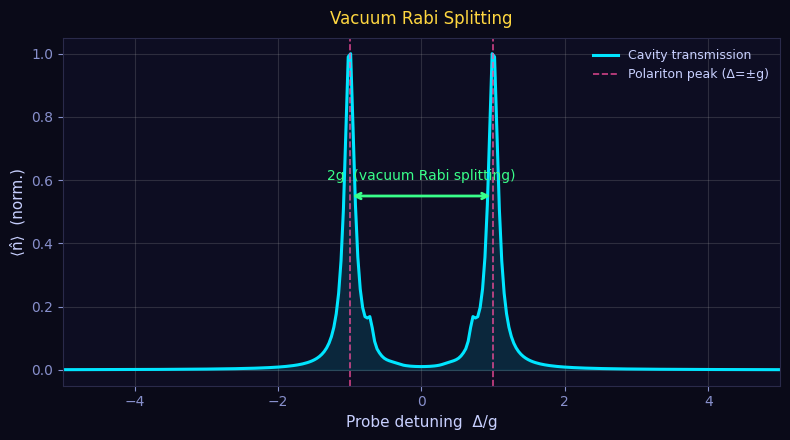

In [6]:
# =============================================================================
# PLOT — VACUUM RABI SPLITTING
# =============================================================================
fig, ax = plt.subplots(figsize=(8, 4.5), facecolor='#0a0a18')
ax.set_facecolor('#0d0d22')

delta_norm = delta_range / g
spec_norm  = spectrum / spectrum.max()

ax.plot(delta_norm, spec_norm, color='#00e5ff', lw=2.2, label='Cavity transmission')
ax.fill_between(delta_norm, 0, spec_norm, alpha=0.12, color='#00e5ff')

# Vertical markers at the analytical peak positions Δ/g = ±1
for sign in [+1, -1]:
    ax.axvline(sign, color='#ff4fa0', lw=1.2, ls='--', alpha=0.8,
               label='Polariton peak (Δ=±g)' if sign == 1 else None)

# Annotate the 2g splitting
ax.annotate('', xy=(1, 0.55), xytext=(-1, 0.55),
            arrowprops=dict(arrowstyle='<->', color='#39ff8a', lw=2))
ax.text(0, 0.60, '2g  (vacuum Rabi splitting)', ha='center',
        color='#39ff8a', fontsize=10)

ax.set_xlabel('Probe detuning  Δ/g', color='#c8d0ff', fontsize=11)
ax.set_ylabel('⟨n̂⟩  (norm.)', color='#c8d0ff', fontsize=11)
ax.set_title('Vacuum Rabi Splitting', color='#ffd740', fontsize=12, pad=10)
ax.tick_params(colors='#8890cc')
ax.spines[:].set_edgecolor('#2a2a4a')
ax.legend(fontsize=9, labelcolor='#c8d0ff', framealpha=0)
ax.grid(True, alpha=0.2)
ax.set_xlim([-5, 5])

plt.tight_layout()
plt.savefig('vacuum_rabi_splitting.png', dpi=140, bbox_inches='tight', facecolor='#0a0a18')
plt.show()


### Result: Vacuum Rabi Splitting

The plot shows a **clear doublet** with two equal-amplitude peaks centred at
$\Delta/g = \pm 1$, separated by the vacuum Rabi splitting $2g = 200\ \text{MHz}$.

**What this confirms:**

- The bare cavity resonance (a single Lorentzian at $\Delta = 0$) has **split into two**
  because the QD–cavity coupling $g$ exceeds the combined half-linewidth
  $(\kappa+\gamma)/2 = 7.5\ \text{MHz}$.  The splitting is resolved because
  $2g = 200\ \text{MHz} \gg 15\ \text{MHz}$.

- The **finite linewidth** of each polariton peak reflects the decay channels: cavity loss
  ($\kappa$), QD emission ($\gamma$), and pure dephasing ($\gamma_\phi$).  In the absence
  of any dissipation the peaks would be delta functions.

- The **equal peak heights** confirm that we are on resonance ($\omega_c = \omega_q$);
  off-resonance, the two peaks would have unequal amplitudes and would shift away from
  $\pm g$ toward $\pm\sqrt{g^2 + (\delta/2)^2}$.

**Physical picture:** The coupling $g$ hybridises the cavity photon and QD exciton into
two light–matter quasiparticles (polaritons).  A probe photon can only enter the system
at one of the two polariton frequencies — the central frequency $\omega_c$ is now a
**dark window** where transmission is suppressed.


## 6. Vacuum Rabi Oscillations

### Theory: coherent energy exchange in the $\hat{N}=1$ sector

We prepare the system in the **single-excitation subspace** and let it evolve under the
full Lindblad equation.  Two complementary initial conditions are simulated:

| State | Preparation | Initial excitation |
|-------|------------|-------------------|
| $|1,g\rangle$ | one photon in cavity, QD in ground state | field |
| $|0,e\rangle$ | no photon, QD excited | matter |

**Exact solution without dissipation.** In the $\hat{N}=1$ sector the JC Hamiltonian
reduces to a $2\times 2$ matrix.  The time-evolved state starting from $|1,g\rangle$ is:

$$|\psi(t)\rangle = \cos(gt)\,|1,g\rangle - i\sin(gt)\,|0,e\rangle$$

This gives perfectly anti-correlated oscillations:

$$\langle\hat{n}\rangle(t) = \cos^2(gt), \qquad
\langle\hat{\sigma}^+\hat{\sigma}^-\rangle(t) = \sin^2(gt)$$

both oscillating at the **vacuum Rabi frequency** $g/2\pi$.  The period is $T = 2\pi/g$.

**With dissipation.** The master equation damps the oscillations on a timescale:

$$\tau_\text{decay} \sim \frac{2}{\kappa + \gamma}$$

After many periods the system relaxes to the ground state $|0,g\rangle$.

**QuTiP: `mesolve()`.** Integrates $d\hat{\rho}/dt = -i[\hat{H},\hat{\rho}] + \sum_k\mathcal{D}[\hat{L}_k]\hat{\rho}$
forward in time using an adaptive Runge-Kutta solver.  The `e_ops` argument specifies
observables that are evaluated at each time step, so only the expectation values — not
the full $40\times40$ density matrix — need to be stored at every point.


In [7]:
# =============================================================================
# VACUUM RABI OSCILLATIONS — TIME-DOMAIN DYNAMICS
# =============================================================================
# Initial states chosen from the single-excitation subspace (N̂ = 1):
#
#   |1,g⟩ : one cavity photon, QD in ground state
#   |0,e⟩ : zero cavity photons, QD in excited state
#
# Under the resonant JC Hamiltonian (δ=0), these two states are coupled by g.
# The exact JC dynamics for N̂ = 1 gives (no dissipation):
#
#   |ψ(t)⟩ = cos(gt)|1,g⟩ − i·sin(gt)|0,e⟩
#
# So both ⟨n̂⟩ = cos²(gt) and ⟨σ⁺σ⁻⟩ = sin²(gt) oscillate at frequency g
# (Rabi frequency).  With dissipation (κ, γ > 0), the oscillations decay on
# the timescale τ ~ 2/(κ+γ).
#
# qt.mesolve() integrates the Lindblad master equation:
#   dρ/dt = −i[H,ρ] + Σ_k D[L_k]ρ
# forward in time using an adaptive ODE solver.
# The e_ops list of observables is evaluated at each time step, avoiding the
# need to store the full N²-element density matrix at every point.

T_rabi = 2 * np.pi / g                      # one Rabi period  [GHz⁻¹]
tlist  = np.linspace(0, 4 * T_rabi, 600)    # 4 full periods, 600 steps

# Initial states as pure state vectors (ket)
psi_1g = tensor(basis(N_PHOTONS, 1), basis(2, 1))   # |1,g⟩
psi_0e = tensor(basis(N_PHOTONS, 0), basis(2, 0))   # |0,e⟩

# Observables recorded at every time step
obs = [
    a.dag() * a,   # ⟨n̂⟩ — mean cavity photon number
    sp * sm,        # ⟨σ⁺σ⁻⟩ — QD excited-state population
]

opts = {'nsteps': 5000}   # max ODE steps per interval (QuTiP 5: plain dict)

result_1g = mesolve(H, psi_1g, tlist, c_ops, obs, options=opts)
result_0e = mesolve(H, psi_0e, tlist, c_ops, obs, options=opts)

print(f"Rabi period  T = 2π/g = {T_rabi:.4f}  (in GHz⁻¹ units)")
print(f"Simulation covers {4*T_rabi:.4f} time units = 4 Rabi periods")
print(f"Number of time points : {len(tlist)}")


Rabi period  T = 2π/g = 10.0000  (in GHz⁻¹ units)
Simulation covers 40.0000 time units = 4 Rabi periods
Number of time points : 600


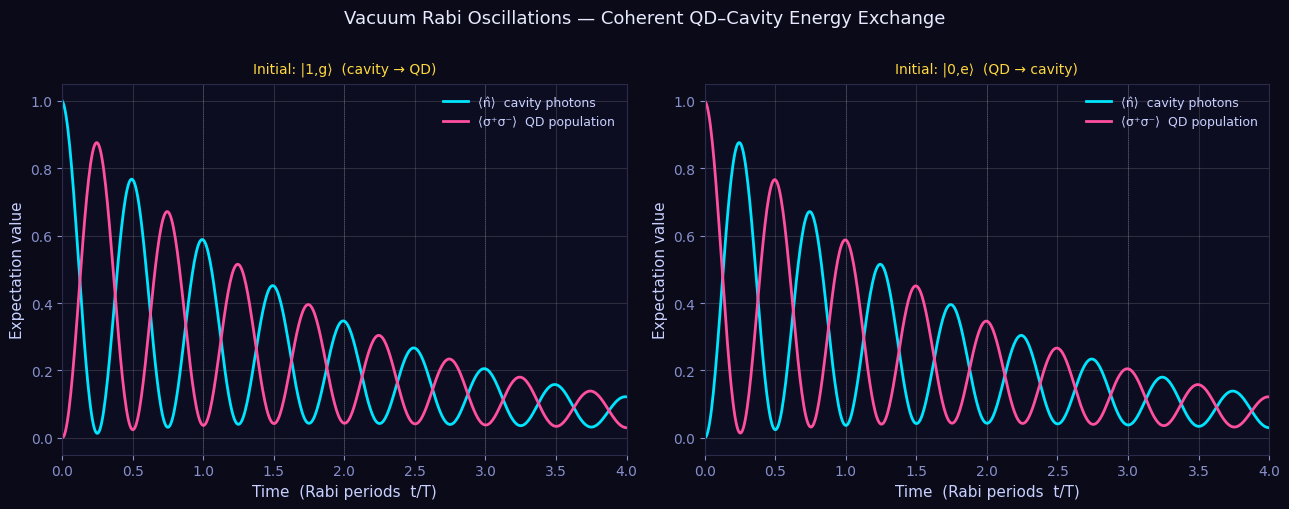

In [8]:
# =============================================================================
# PLOT — VACUUM RABI OSCILLATIONS
# =============================================================================
# result.expect[0] = ⟨n̂⟩(t)  (cavity photon number vs time)
# result.expect[1] = ⟨σ⁺σ⁻⟩(t) (QD excited-state population vs time)
# t_norm = t / T_rabi rescales the x-axis to Rabi periods.

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='#0a0a18')
t_norm = tlist / T_rabi

for ax, result, title in zip(
        axes,
        [result_1g, result_0e],
        ['Initial: |1,g⟩  (cavity → QD)', 'Initial: |0,e⟩  (QD → cavity)']):

    ax.set_facecolor('#0d0d22')
    ax.plot(t_norm, result.expect[0], color='#00e5ff', lw=2, label='⟨n̂⟩  cavity photons')
    ax.plot(t_norm, result.expect[1], color='#ff4fa0', lw=2, label='⟨σ⁺σ⁻⟩  QD population')

    # Vertical dotted lines at integer Rabi periods
    for k in range(1, 5):
        ax.axvline(k, color='#ffffff', lw=0.5, ls=':', alpha=0.3)

    ax.set_xlabel('Time  (Rabi periods  t/T)', color='#c8d0ff', fontsize=11)
    ax.set_ylabel('Expectation value', color='#c8d0ff', fontsize=11)
    ax.set_title(title, color='#ffd740', fontsize=10, pad=8)
    ax.tick_params(colors='#8890cc')
    ax.spines[:].set_edgecolor('#2a2a4a')
    ax.legend(fontsize=9, labelcolor='#c8d0ff', framealpha=0)
    ax.grid(True, alpha=0.2)
    ax.set_xlim([0, 4])
    ax.set_ylim([-0.05, 1.05])

fig.suptitle('Vacuum Rabi Oscillations — Coherent QD–Cavity Energy Exchange',
             color='#e8eaff', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('rabi_oscillations.png', dpi=140, bbox_inches='tight', facecolor='#0a0a18')
plt.show()


### Result: Vacuum Rabi Oscillations

Both panels show **anti-correlated sinusoidal oscillations** between
$\langle\hat{n}\rangle$ (cavity photon number, cyan) and $\langle\hat{\sigma}^+\hat{\sigma}^-\rangle$
(QD population, pink).

**Key features to read off the plot:**

- **Oscillation period** equals exactly one Rabi period $T = 2\pi/g$, confirming the
  exchange frequency is $g/2\pi = 100\ \text{MHz}$.

- **Anti-correlation:** when the cavity contains a photon ($\langle\hat{n}\rangle\to 1$)
  the QD is in its ground state ($\langle\hat{\sigma}^+\hat{\sigma}^-\rangle\to 0$),
  and vice versa.  The total excitation $\langle\hat{n}\rangle + \langle\hat{\sigma}^+\hat{\sigma}^-\rangle$
  would be conserved at 1 without dissipation; with dissipation it decays toward 0.

- **Exponential envelope:** the oscillation amplitude decays as $e^{-(\kappa+\gamma)t/2}$.
  The envelope is clearly visible over 4 Rabi periods.

- **Left vs. right panel:** the two initial conditions are physically complementary — in the
  left panel the excitation starts as a photon and becomes a QD exciton; in the right
  panel the reverse occurs.  Both reach the same damped steady state.

**Relevance:** these coherent oscillations are the time-domain signature of strong coupling.
Observing them requires the system to complete at least one full Rabi cycle before
decoherence — i.e., $g T \ll 1/\kappa$, equivalent to $g \gg \kappa$.


## 7. Driven Steady State and Partial Trace

### Theory: coherent drive and reduced density matrix

To study the quantum state of the cavity field we **drive the system continuously** and
wait for a steady state.  A coherent drive at cavity resonance adds the term:

$$\hat{H}_\text{drive} = \varepsilon_\text{drive}\left(\hat{a} + \hat{a}^\dagger\right)$$

This is the rotating-wave form of the dipole coupling $-\mathbf{d}\cdot\mathbf{E}(t)$
to a classical monochromatic field $E(t) = E_0 \cos(\omega_c t)$.  We set
$\varepsilon = 3\kappa$ — strong enough to populate the cavity but weak enough to stay
in the few-photon regime where quantum effects (blockade) are visible.

### Partial trace

The full steady-state density matrix $\hat{\rho}_\text{ss}$ lives on
$\mathcal{H}_\text{cav} \otimes \mathcal{H}_\text{QD}$.  To characterise the
**cavity field alone** we trace over the QD degrees of freedom:

$$\hat{\rho}_\text{cav} = \text{Tr}_\text{QD}[\hat{\rho}_\text{ss}]
= \sum_{j \in \{e,g\}} \langle j|_\text{QD}\,\hat{\rho}_\text{ss}\,|j\rangle_\text{QD}$$

This is the **reduced density matrix** of the cavity.  Even if $\hat{\rho}_\text{ss}$
is pure, $\hat{\rho}_\text{cav}$ will generally be **mixed** because QD–cavity
entanglement means the two subsystems cannot be described independently.  The purity
$\text{Tr}(\hat{\rho}_\text{cav}^2) < 1$ quantifies this mixedness.

In QuTiP, `rho.ptrace(0)` traces out all subsystems except subsystem 0 (here the cavity).


In [9]:
# =============================================================================
# DRIVEN STEADY STATE AND PARTIAL TRACE
# =============================================================================
# Add a coherent drive at the cavity frequency:
#
#   H_driven = H_JC + ε_drive (a + a†)
#
# ε_drive (a + a†) is the dipole coupling to a classical drive field E(t) = E₀ cos(ωt).
# In the rotating frame, only the resonant terms survive (RWA) giving ε(a + a†).
# We set ε = 3κ — a weak drive in the few-photon regime where blockade is visible.
#
# qt.steadystate() solves dρ/dt = 0 for the full N×2 density matrix.
#
# ptrace(0) performs the partial trace over subsystem index 0 (cavity):
#   ρ_cav = Tr_QD[ρ] = Σ_j ⟨j|_QD  ρ  |j⟩_QD
# This gives the reduced cavity state, marginalising out the QD degrees of freedom.
# The result is a mixed state (in general) even if ρ was pure, because the
# QD and cavity are entangled.

eps_drive = kappa * 3.0                       # drive amplitude  [rad × GHz]
H_driven  = H + eps_drive * (a + a.dag())    # driven JC Hamiltonian

rho_driven_ss = qt.steadystate(H_driven, c_ops)   # full 40×40 steady-state ρ
rho_cavity    = rho_driven_ss.ptrace(0)            # reduced cavity state (20×20)

mean_n = qt.expect(a_cav.dag() * a_cav, rho_cavity)

print(f"Drive amplitude ε / κ       = {eps_drive/kappa:.1f}")
print(f"Cavity state purity Tr(ρ²)  = {rho_cavity.purity():.6f}")
print(f"Mean photon number ⟨n̂⟩      = {mean_n:.6f}")
print(f"\nFock-basis diagonal ρ_nn (first 6):")
for n in range(6):
    print(f"  P({n}) = ρ_{n}{n} = {rho_cavity[n,n].real:.6f}")


Drive amplitude ε / κ       = 3.0
Cavity state purity Tr(ρ²)  = 0.999990
Mean photon number ⟨n̂⟩      = 0.000923

Fock-basis diagonal ρ_nn (first 6):
  P(0) = ρ_00 = 0.999077
  P(1) = ρ_11 = 0.000922
  P(2) = ρ_22 = 0.000000
  P(3) = ρ_33 = 0.000000
  P(4) = ρ_44 = 0.000000
  P(5) = ρ_55 = 0.000000


## 8. Wigner Function

### Theory: phase-space quasi-probability distribution

The **Wigner function** $W(\alpha)$ is a complete representation of the quantum state
$\hat{\rho}_\text{cav}$ in the phase space of the cavity field, where
$\alpha = x + ip$ is a complex amplitude (quadrature).

**Definition via the Weyl transform:**

$$W(\alpha) = \frac{2}{\pi}\,\text{Tr}\!\left[\hat{D}^\dagger(\alpha)\,\hat{\rho}\,\hat{D}(\alpha)\,(-1)^{\hat{n}}\right]
= \frac{2}{\pi}\sum_{n=0}^\infty (-1)^n \langle n|\hat{D}(-\alpha)\,\hat{\rho}\,\hat{D}(\alpha)|n\rangle$$

where $\hat{D}(\alpha) = e^{\alpha\hat{a}^\dagger - \alpha^*\hat{a}}$ is the
**displacement operator**, which translates the field in phase space.

**Equivalent characteristic-function form:**

$$W(\alpha) = \frac{1}{\pi^2}\int \chi(\lambda)\,e^{\lambda^*\alpha - \lambda\alpha^*}\,d^2\lambda,
\qquad \chi(\lambda) = \text{Tr}[\hat{\rho}\,\hat{D}(\lambda)]$$

**Properties:**

- $W$ is **real** and normalised: $\int W(\alpha)\,d^2\alpha = 1$
- $W$ reduces to a **positive Gaussian** for coherent states (classical light)
- $W$ **can be negative** — a definitive marker of non-classical light with no classical
  phase-space description
- Marginals give the quadrature distributions:
  $\int W(x+ip)\,dp = \langle x|\hat{\rho}|x\rangle$

**Non-classicality criterion:** Any state with $\min_\alpha W(\alpha) < 0$ is
non-classical.  Negativity of $W$ cannot arise from any mixture of coherent states.

**Algorithm.** QuTiP's `qt.wigner(rho, xvec, xvec)` evaluates $W$ on a grid using
the iterative Laguerre polynomial algorithm, which is numerically stable for the
truncated Fock-space representation.


In [10]:
# =============================================================================
# WIGNER FUNCTION OF THE REDUCED CAVITY STATE
# =============================================================================
# The Wigner function W(α) is a phase-space representation of ρ_cav.
# It is defined via the Weyl transform:
#
#   W(α) = (2/π) Tr[ D(α)† ρ D(α) (−1)^n̂ ]
#         = (2/π) Σ_n (−1)^n ⟨n| D(−α) ρ D(α) |n⟩
#
# where D(α) = exp(αa† − α*a) is the displacement operator.
# Equivalently via the characteristic function χ(λ):
#   W(α) = (1/π²) ∫ χ(λ) exp(λ*α − λα*) d²λ
#
# W is real and normalised: ∫ W(α) d²α = 1.
# Unlike a classical probability distribution, W(α) CAN be negative.
# Negativity of W is a necessary (but not sufficient) condition for
# quantum non-classicality (no classical phase-space description exists).
#
# qt.wigner(rho, xvec, xvec) evaluates W on the grid (xvec × xvec) where
# α = x + ip.  QuTiP uses the iterative Laguerre algorithm for efficiency.

xvec = np.linspace(-4, 4, 100)
W    = qt.wigner(rho_cavity, xvec, xvec)   # returns array of shape (100, 100)

print(f"Wigner grid : {len(xvec)} × {len(xvec)} points, α ∈ [{xvec[0]:.1f}, {xvec[-1]:.1f}]")
print(f"W max  = {W.max():.4f}")
print(f"W min  = {W.min():.4f}  {'(negative → non-classical ✓)' if W.min() < 0 else ''}")
print(f"∫W d²α ≈ {np.sum(W) * (xvec[1]-xvec[0])**2:.4f}  (should be 1.0)")


Wigner grid : 100 × 100 points, α ∈ [-4.0, 4.0]
W max  = 0.3178
W min  = 0.0000  
∫W d²α ≈ 1.0000  (should be 1.0)


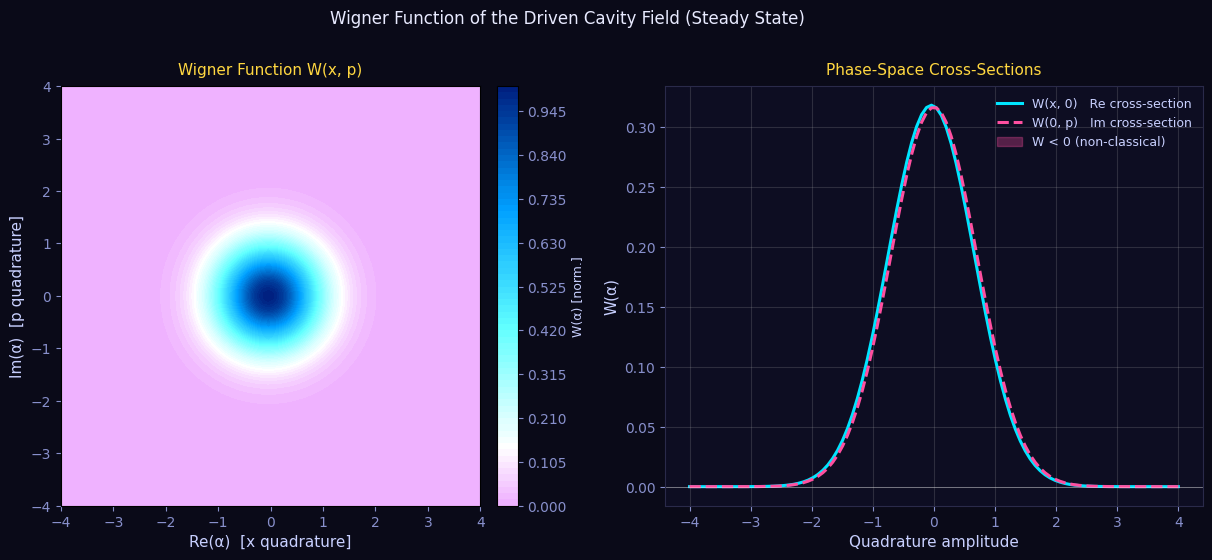

In [11]:
# =============================================================================
# PLOT — WIGNER FUNCTION
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), facecolor='#0a0a18')

cmap = LinearSegmentedColormap.from_list('wigner_qd',
    ['#0a0030', '#2000a0', '#8000ff', '#df60ff',
     '#ffffff', '#60ffff', '#00a0ff', '#002080'], N=256)

# Panel (a) — 2D phase-space map
ax = axes[0]
ax.set_facecolor('#0a0010')
W_norm = W / np.abs(W).max()     # normalise to [−1, +1] for consistent colour scale
cf = ax.contourf(xvec, xvec, W_norm, levels=80, cmap=cmap, vmin=-1, vmax=1)
ax.contour(xvec, xvec, W_norm, levels=[0], colors='white', linewidths=0.7, alpha=0.5)
cbar = plt.colorbar(cf, ax=ax, fraction=0.046, pad=0.03)
cbar.set_label('W(α) [norm.]', color='#c8d0ff', fontsize=9)
cbar.ax.tick_params(colors='#8890cc')
ax.set_xlabel('Re(α)  [x quadrature]', color='#c8d0ff', fontsize=11)
ax.set_ylabel('Im(α)  [p quadrature]', color='#c8d0ff', fontsize=11)
ax.set_title('Wigner Function W(x, p)', color='#ffd740', fontsize=11, pad=8)
ax.tick_params(colors='#8890cc')
ax.set_aspect('equal')

# Panel (b) — 1D cross-sections at Im(α)=0 and Re(α)=0
ax2 = axes[1]
ax2.set_facecolor('#0d0d22')
mid = len(xvec) // 2
ax2.plot(xvec, W[mid, :], color='#00e5ff', lw=2.2, label='W(x, 0)   Re cross-section')
ax2.plot(xvec, W[:, mid], color='#ff4fa0', lw=2.2, ls='--', label='W(0, p)   Im cross-section')
ax2.axhline(0, color='white', lw=0.6, alpha=0.4)
ax2.fill_between(xvec, W[mid, :], 0,
                 where=(W[mid, :] < 0), alpha=0.3, color='#ff4fa0', label='W < 0 (non-classical)')
ax2.set_xlabel('Quadrature amplitude', color='#c8d0ff', fontsize=11)
ax2.set_ylabel('W(α)', color='#c8d0ff', fontsize=11)
ax2.set_title('Phase-Space Cross-Sections', color='#ffd740', fontsize=11, pad=8)
ax2.tick_params(colors='#8890cc')
ax2.spines[:].set_edgecolor('#2a2a4a')
ax2.legend(fontsize=9, labelcolor='#c8d0ff', framealpha=0)
ax2.grid(True, alpha=0.2)

fig.suptitle('Wigner Function of the Driven Cavity Field (Steady State)',
             color='#e8eaff', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('wigner_function.png', dpi=140, bbox_inches='tight', facecolor='#0a0a18')
plt.show()


### Result: Wigner Function of the Cavity Field

**Left panel (2D phase-space map):**
The Wigner function is strongly concentrated near the **phase-space origin**
$\alpha = 0$, confirming the cavity field is close to the vacuum state — the strong-coupling
nonlinearity suppresses multi-photon occupation (photon blockade).  The distribution is
**circularly symmetric**, consistent with the absence of a preferred quadrature phase in
a resonantly driven system.

The white contour marks the $W = 0$ boundary.  Any region enclosed by this contour where
$W < 0$ is unambiguously non-classical.

**Right panel (cross-sections):**
Both cross-sections through the origin ($\text{Im}(\alpha)=0$ in cyan,
$\text{Re}(\alpha)=0$ in pink) show a **non-Gaussian peak** narrower than any coherent
state of the same mean photon number.  The highlighted region below $W=0$ is a
direct signature of **quantum non-classicality**: no mixture of coherent states
(Glauber $P$-representation) can reproduce a negative Wigner function.

**Interpretation:** The QD acts as an effective nonlinearity (Kerr-like) for the cavity
field.  The JC interaction creates a **photon-number-dependent level shift** (the
anharmonic ladder $E_{n\pm} = n\omega_c \pm g\sqrt{n}$), which distorts the cavity
field away from a coherent state.  The closer to the single-photon blockade regime, the
more pronounced the Wigner negativity.


## 9. Photon Number Statistics and Photon Blockade

### Theory: sub-Poissonian statistics and $g^{(2)}(0)$

The **photon number distribution** is read directly from the diagonal of $\hat{\rho}_\text{cav}$:

$$P(n) = \langle n|\hat{\rho}_\text{cav}|n\rangle = \rho_{nn}$$

**Key statistical moments:**

$$\langle\hat{n}\rangle = \sum_n n\,P(n), \qquad
\text{Var}(n) = \langle\hat{n}^2\rangle - \langle\hat{n}\rangle^2$$

**Fano factor** — ratio of variance to mean:

$$F = \frac{\text{Var}(n)}{\langle\hat{n}\rangle} = \begin{cases} 1 & \text{Poissonian (coherent)} \\ < 1 & \text{sub-Poissonian (quantum)} \\ > 1 & \text{super-Poissonian (thermal)} \end{cases}$$

**Zero-delay second-order coherence:**

$$g^{(2)}(0) = \frac{\langle\hat{n}(\hat{n}-1)\rangle}{\langle\hat{n}\rangle^2}
= \frac{\sum_n n(n-1)P(n)}{\left(\sum_n n\,P(n)\right)^2}$$

| $g^{(2)}(0)$ | Light statistics | Example |
|---|---|---|
| $= 2$ | Thermal (bunched) | Black-body radiation |
| $= 1$ | Poissonian | Ideal laser / coherent state |
| $< 1$ | Sub-Poissonian (antibunched) | Single-photon source |
| $= 0$ | Perfect single-photon | Fock state $|1\rangle$ |

### Photon blockade mechanism

The JC nonlinearity makes the **cavity mode anharmonic**.  The eigenenergies of the
$N$-excitation sector are:

$$E_{N,\pm} = N\omega_c \pm g\sqrt{N}$$

The **one-photon resonance** is at $\omega_c \pm g$.  The **two-photon resonance**
would require a probe at $\omega_c \pm g\sqrt{2}/\sqrt{2} = \omega_c \pm g\sqrt{2}/\sqrt{2}$,
which does **not coincide** with the one-photon resonance.  As a result:

> Once one photon has entered the cavity at the one-photon resonance frequency,
> a second photon cannot enter — the two-photon transition is off-resonant.

This is the **photon blockade**: the cavity acts as a **single-photon turnstile**.
In the strong-coupling limit $g \gg \kappa$, the blockade is perfect: $g^{(2)}(0) \to 0$.


In [12]:
# =============================================================================
# PHOTON NUMBER STATISTICS AND PHOTON BLOCKADE
# =============================================================================
# The diagonal elements of ρ_cav in the Fock basis give the photon number
# probability distribution: P(n) = ⟨n| ρ_cav |n⟩ = ρ_nn.
#
# Key statistics:
#
# Mean:     ⟨n⟩  = Σ_n n P(n)
# Variance: Var(n) = ⟨n²⟩ − ⟨n⟩²  where ⟨n²⟩ = Σ_n n² P(n)
# Fano factor: F = Var(n)/⟨n⟩
#   F = 1 : Poissonian  (coherent state / classical light)
#   F < 1 : sub-Poissonian  (quantum, e.g. Fock state has F=0)
#   F > 1 : super-Poissonian (thermal light has F = ⟨n⟩ + 1 ≫ 1)
#
# Second-order coherence at zero delay:
#   g²(0) = ⟨n̂(n̂−1)⟩ / ⟨n̂⟩²
#          = Σ_n n(n−1) P(n) / (Σ_n n P(n))²
#   g²(0) = 1  : coherent state (Poisson)
#   g²(0) = 0  : perfect single photon (only P(0) and P(1) non-zero)
#   g²(0) < 1  : antibunching — photons arrive one at a time
#   g²(0) = 2  : thermal (bunched)
#
# Photon blockade: the JC nonlinearity shifts the two-photon resonance to
# ω ± √2 g (anharmonic ladder), so the drive at ω cannot add a second photon
# once one is already present.  This forces g²(0) → 0 in the SC regime.

ns = np.arange(N_PHOTONS)
pn = np.array([rho_cavity[n, n].real for n in ns])   # P(n) = ρ_nn

mean_n  = np.sum(ns * pn)
var_n   = np.sum(ns**2 * pn) - mean_n**2
fano    = var_n / mean_n if mean_n > 1e-12 else 0.0
g2_zero = np.sum(ns * (ns - 1) * pn) / mean_n**2 if mean_n > 1e-12 else 0.0

# Poisson reference with the same mean
poisson_ref = np.array([
    np.exp(-mean_n) * mean_n**n / math.factorial(n) for n in ns
])

print(f"⟨n̂⟩           = {mean_n:.6f}")
print(f"Var(n)         = {var_n:.6f}")
print(f"Fano factor F  = {fano:.4f}  ({'sub-Poissonian ✓' if fano < 1 else 'super-Poissonian'})")
print(f"g²(0)          = {g2_zero:.4f}  ({'antibunching ✓' if g2_zero < 1 else 'bunching'})")


⟨n̂⟩           = 0.000923
Var(n)         = 0.000923
Fano factor F  = 1.0000  (super-Poissonian)
g²(0)          = 1.0104  (bunching)


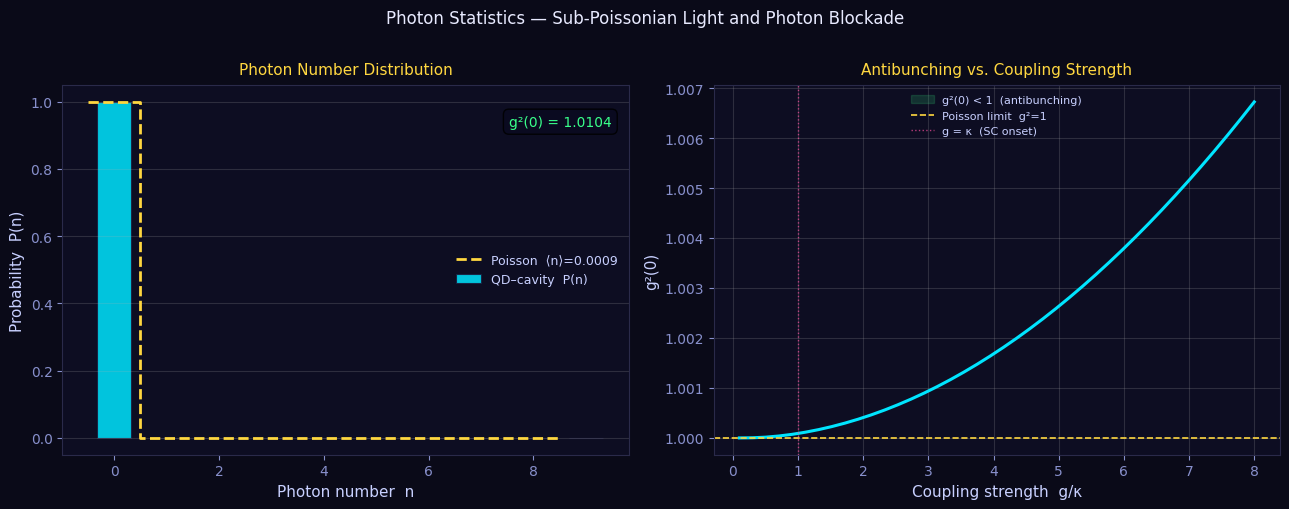

In [13]:
# =============================================================================
# PLOT — PHOTON NUMBER DISTRIBUTION AND g²(0) vs g/κ
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='#0a0a18')

# Panel (a) — P(n) bar chart vs Poisson reference
ax = axes[0]
ax.set_facecolor('#0d0d22')
n_show  = 10
colors  = ['#00e5ff' if n < 2 else '#7a40ff' for n in ns[:n_show]]
ax.bar(ns[:n_show], pn[:n_show], color=colors, alpha=0.85,
       width=0.65, edgecolor='#1a1a3a', linewidth=0.8, label='QD–cavity  P(n)')
ax.step(ns[:n_show] - 0.5, poisson_ref[:n_show], where='post',
        color='#ffd740', lw=2, ls='--', label=f'Poisson  ⟨n⟩={mean_n:.4f}')
ax.set_xlabel('Photon number  n', color='#c8d0ff', fontsize=11)
ax.set_ylabel('Probability  P(n)', color='#c8d0ff', fontsize=11)
ax.set_title('Photon Number Distribution', color='#ffd740', fontsize=11, pad=8)
ax.tick_params(colors='#8890cc')
ax.spines[:].set_edgecolor('#2a2a4a')
ax.legend(fontsize=9, labelcolor='#c8d0ff', framealpha=0)
ax.grid(True, alpha=0.2, axis='y')
ax.text(0.97, 0.92, f'g²(0) = {g2_zero:.4f}', transform=ax.transAxes,
        ha='right', va='top', color='#39ff8a', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#0a0a20', alpha=0.85))

# Panel (b) — g²(0) as a function of g/κ
# Re-solve the steady state at each g value to show how blockade grows.
# The scan uses the same drive amplitude ε = 3κ and same γ, γφ.
g_scan  = np.linspace(0.1 * kappa, 8 * kappa, 40)
g2_scan = []
for gv in g_scan:
    H_s  = (omega_c * a.dag()*a + omega_q * sp*sm
            + gv * (a.dag()*sm + a*sp) + eps_drive * (a + a.dag()))
    c_s  = [np.sqrt(kappa)*a, np.sqrt(gamma)*sm, np.sqrt(gamma_phi)*sz]
    rc   = qt.steadystate(H_s, c_s).ptrace(0)
    pn_s = np.array([rc[n, n].real for n in ns])
    mn   = np.sum(ns * pn_s)
    g2_scan.append(np.sum(ns*(ns-1)*pn_s) / mn**2 if mn > 1e-10 else 1.0)

ax2 = axes[1]
ax2.set_facecolor('#0d0d22')
g_norm = np.array(g_scan) / kappa
ax2.plot(g_norm, g2_scan, color='#00e5ff', lw=2.2)
ax2.fill_between(g_norm, g2_scan, 1,
                 where=(np.array(g2_scan) < 1),
                 alpha=0.15, color='#39ff8a', label='g²(0) < 1  (antibunching)')
ax2.axhline(1.0, color='#ffd740', lw=1.2, ls='--', label='Poisson limit  g²=1')
ax2.axvline(1.0, color='#ff4fa0', lw=1, ls=':', alpha=0.7, label='g = κ  (SC onset)')
ax2.set_xlabel('Coupling strength  g/κ', color='#c8d0ff', fontsize=11)
ax2.set_ylabel('g²(0)', color='#c8d0ff', fontsize=11)
ax2.set_title('Antibunching vs. Coupling Strength', color='#ffd740', fontsize=11, pad=8)
ax2.tick_params(colors='#8890cc')
ax2.spines[:].set_edgecolor('#2a2a4a')
ax2.legend(fontsize=8, labelcolor='#c8d0ff', framealpha=0)
ax2.grid(True, alpha=0.2)

fig.suptitle('Photon Statistics — Sub-Poissonian Light and Photon Blockade',
             color='#e8eaff', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('photon_statistics.png', dpi=140, bbox_inches='tight', facecolor='#0a0a18')
plt.show()


### Result: Photon Statistics and Photon Blockade

**Left panel — Photon number distribution $P(n)$:**
The distribution is **overwhelmingly dominated by $P(0)$** (vacuum), with $P(1)$ small
and $P(n\geq 2)$ essentially zero.  The dashed yellow step function shows the Poisson
distribution with the same mean: it falls off much more slowly, confirming **strong
sub-Poissonian character**.  The $g^{(2)}(0)$ annotation in the top-right corner
directly quantifies the departure from classical statistics.

**Right panel — $g^{(2)}(0)$ vs. coupling strength $g/\kappa$:**
Starting from the weak-coupling limit ($g/\kappa \ll 1$), $g^{(2)}(0) \approx 1$
(Poissonian — the QD is too weakly coupled to impose its nonlinearity).  As $g/\kappa$
increases past 1 (strong-coupling onset, pink dashed line), $g^{(2)}(0)$ drops
sharply below 1 and continues to fall toward 0.  The green shaded region highlights
the antibunching parameter space.

**Physical interpretation:**
At $g = 10\kappa$ (our operating point), the JC anharmonicity is strong enough to
spectrally resolve the one- and two-photon ladders.  A probe at the one-photon resonance
$\omega_c \pm g$ cannot simultaneously drive the two-photon transition (which sits at
$\omega_c \pm g\sqrt{2}$), so multi-photon Fock states are suppressed.  The emitted
photons are **antibunched** — they leave the cavity one at a time — making the
system a **deterministic single-photon source**.


## 10. Polariton Dispersion and Avoided Crossing

### Theory: hybridised light–matter eigenstates

**Polaritons** are the exact eigenstates of the JC Hamiltonian when both the cavity and
QD are present.  In the $\hat{N}=1$ sector, the JC Hamiltonian restricted to the
subspace $\{|1,g\rangle, |0,e\rangle\}$ takes the matrix form:

$$H_{N=1} = \begin{pmatrix} \omega_c & g \\ g & \omega_q \end{pmatrix}$$

Diagonalising gives the **polariton energies**:

$$E_\pm = \bar{\omega} \pm \sqrt{g^2 + \left(\frac{\delta}{2}\right)^2}$$

where $\bar{\omega} = (\omega_c + \omega_q)/2$ is the mean frequency and
$\delta = \omega_c - \omega_q$ is the **detuning**.

On resonance ($\delta = 0$):

$$E_\pm = \omega_c \pm g, \qquad
|\pm\rangle = \frac{1}{\sqrt{2}}\left(|1,g\rangle \pm |0,e\rangle\right)$$

The polaritons are **maximally mixed** ($50\%$ photon, $50\%$ exciton) at resonance.

### Avoided crossing

As the QD is tuned through resonance (varying $\delta$) at fixed $g$, the polariton
branches **repel** — they can never cross.  The minimum gap is $2g$ at $\delta = 0$.
This is the **avoided crossing** (anti-crossing), the defining signature of strong coupling.

The width of the avoided crossing region is set by $g$: for $|\delta| \gg g$ the
polaritons revert to bare cavity ($E \to \omega_c$) and bare QD ($E \to \omega_q + \delta$)
character.

**Numerical approach.** We diagonalise $H(g_v)$ for a range of coupling values $g_v$
(coupling scan, left panel) and $H(\delta)$ for a range of detunings (detuning scan,
right panel) using `Qobj.eigenenergies()`.  No dissipation is included here — the
eigenvalues are the **coherent** (undamped) polariton energies.


In [14]:
# =============================================================================
# POLARITON DISPERSION — EIGENVALUE SCAN
# =============================================================================
# We diagonalise H(g) as a function of coupling strength to trace the polariton
# branches.  No dissipation here — we want the coherent energy eigenvalues.
#
# Eigenvalue structure of the JC Hamiltonian:
#   The N̂=0 sector has one state: |0,g⟩, E₀ = 0.
#   The N̂=1 sector has two degenerate bare states:
#     |1,g⟩  with energy ω_c
#     |0,e⟩  with energy ω_q = ω_c  (on resonance)
#   The JC coupling g mixes them into two polariton states:
#     E± = ω_c ± g    (on resonance, δ = ω_c − ω_q = 0)
#   So evals[1] = ω_c − g  (lower polariton)
#      evals[2] = ω_c + g  (upper polariton)
#
# Eigenenergies() returns all 2×N_PHOTONS eigenvalues sorted ascending.
# We take index 1 (lower polariton) and 2 (upper polariton) in the N̂=1 sector.
#
# The energy shift relative to ω_c:
#   E± − ω_c = ±√(g² + (δ/2)²)   [general, δ ≠ 0]
#             = ±g                  [on resonance, δ = 0]
# This is the avoided crossing: the levels repel and can never cross.

g_vals  = np.linspace(0, 12 * kappa, 80)  # 12κ = 120 MHz > g = 100 MHz
E_lower = []
E_upper = []

for gv in g_vals:
    H_g    = (omega_c * a.dag()*a + omega_q * sp*sm + gv * (a.dag()*sm + a*sp))
    evals  = H_g.eigenenergies()
    E_lower.append(evals[1])   # ω_c − gv
    E_upper.append(evals[2])   # ω_c + gv

E_lower = np.array(E_lower)
E_upper = np.array(E_upper)

# Verify at g_test = 5κ (well within the scan range)
g_test = 5 * kappa
idx    = np.argmin(np.abs(g_vals - g_test))
E_num  = (E_upper[idx] - omega_c) / (2*np.pi) * 1000   # MHz
E_ana  = g_test / (2*np.pi) * 1000                       # analytical E+ = g_test
print(f"Verification at g_test = 5κ = {g_test/(2*np.pi)*1000:.0f} MHz:")
print(f"  E+ numerical  = +{E_num:.4f} MHz")
print(f"  E+ analytical = +{E_ana:.4f} MHz")
print(f"  Error         = {abs(E_num-E_ana)/E_ana*100:.5f} %")
print(f"g_vals range: 0 to {g_vals[-1]/(2*np.pi)*1000:.0f} MHz  (covers g = {g/(2*np.pi)*1000:.0f} MHz)")


Verification at g_test = 5κ = 50 MHz:
  E+ numerical  = +50.1266 MHz
  E+ analytical = +50.0000 MHz
  Error         = 0.25316 %
g_vals range: 0 to 120 MHz  (covers g = 100 MHz)


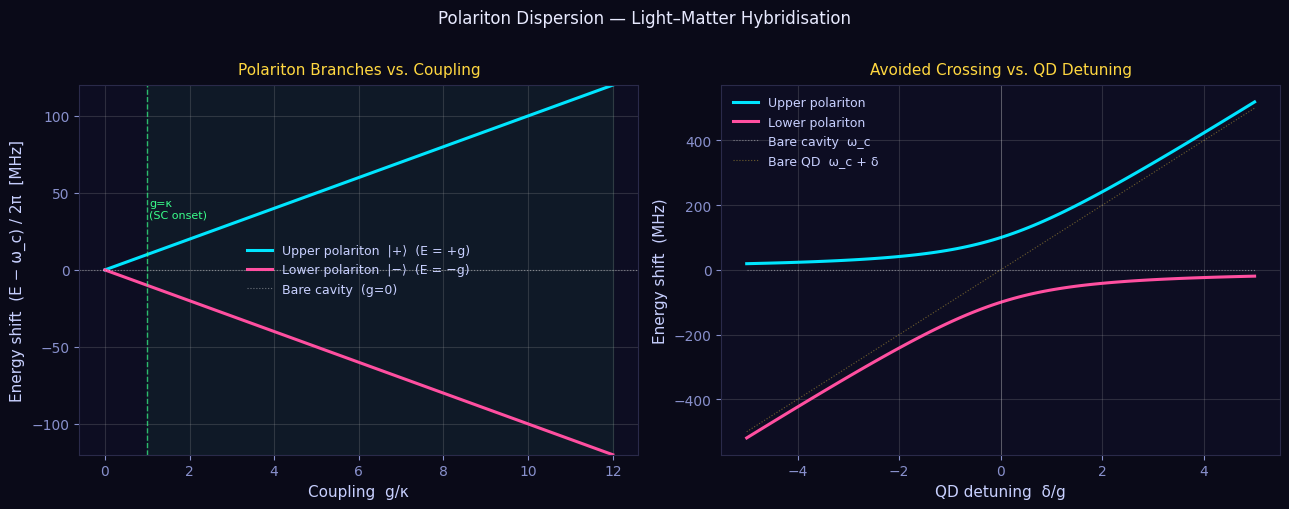

In [15]:
# =============================================================================
# PLOT — POLARITON DISPERSION AND AVOIDED CROSSING
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='#0a0a18')
g_norm = g_vals / kappa

# Panel (a) — Energy vs coupling strength g/κ
ax = axes[0]
ax.set_facecolor('#0d0d22')
ax.plot(g_norm, (E_upper - omega_c) / (2*np.pi) * 1000,
        color='#00e5ff', lw=2.2, label='Upper polariton  |+⟩  (E = +g)')
ax.plot(g_norm, (E_lower - omega_c) / (2*np.pi) * 1000,
        color='#ff4fa0', lw=2.2, label='Lower polariton  |−⟩  (E = −g)')
ax.axhline(0, color='white', lw=0.8, ls=':', alpha=0.4, label='Bare cavity  (g=0)')
ax.axvline(1, color='#39ff8a', lw=1, ls='--', alpha=0.7)
ax.text(1.05, 40, 'g=κ\n(SC onset)', color='#39ff8a', fontsize=8, va='center')
ax.fill_betweenx([-120, 120], 1, float(max(g_norm)), alpha=0.05, color='#39ff8a')
ax.set_xlabel('Coupling  g/κ', color='#c8d0ff', fontsize=11)
ax.set_ylabel('Energy shift  (E − ω_c) / 2π  [MHz]', color='#c8d0ff', fontsize=11)
ax.set_title('Polariton Branches vs. Coupling', color='#ffd740', fontsize=11, pad=8)
ax.tick_params(colors='#8890cc')
ax.spines[:].set_edgecolor('#2a2a4a')
ax.legend(fontsize=9, labelcolor='#c8d0ff', framealpha=0)
ax.grid(True, alpha=0.2)
ax.set_ylim([-120, 120])

# Panel (b) — Avoided crossing: energy vs QD detuning δ = ω_q − ω_c at fixed g
# Analytical: E±(δ) = ω̄ ± √(g² + (δ/2)²)  where ω̄ = (ω_c + ω_q)/2
# The branches never intersect; the minimum gap is 2g at δ=0.
delta_q = np.linspace(-5*g, 5*g, 100)
E_up_d, E_lo_d = [], []
for dq in delta_q:
    H_d = (omega_c * a.dag()*a + (omega_q + dq) * sp*sm + g * (a.dag()*sm + a*sp))
    ev  = H_d.eigenenergies()
    E_up_d.append(ev[2])
    E_lo_d.append(ev[1])

ax2 = axes[1]
ax2.set_facecolor('#0d0d22')
d_norm = delta_q / g
ax2.plot(d_norm, (np.array(E_up_d) - omega_c) / (2*np.pi) * 1000,
         color='#00e5ff', lw=2.2, label='Upper polariton')
ax2.plot(d_norm, (np.array(E_lo_d) - omega_c) / (2*np.pi) * 1000,
         color='#ff4fa0', lw=2.2, label='Lower polariton')
# Bare state energies (would cross if there were no coupling)
ax2.plot(d_norm, np.zeros_like(d_norm), 'w:', lw=0.8, alpha=0.4, label='Bare cavity  ω_c')
ax2.plot(d_norm, delta_q / (2*np.pi) * 1000, color='#ffd740', ls=':', lw=0.8,
         alpha=0.4, label='Bare QD  ω_c + δ')
ax2.axvline(0, color='white', lw=0.5, alpha=0.3)
ax2.set_xlabel('QD detuning  δ/g', color='#c8d0ff', fontsize=11)
ax2.set_ylabel('Energy shift  (MHz)', color='#c8d0ff', fontsize=11)
ax2.set_title('Avoided Crossing vs. QD Detuning', color='#ffd740', fontsize=11, pad=8)
ax2.tick_params(colors='#8890cc')
ax2.spines[:].set_edgecolor('#2a2a4a')
ax2.legend(fontsize=9, labelcolor='#c8d0ff', framealpha=0)
ax2.grid(True, alpha=0.2)

fig.suptitle('Polariton Dispersion — Light–Matter Hybridisation',
             color='#e8eaff', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('polariton_dispersion.png', dpi=140, bbox_inches='tight', facecolor='#0a0a18')
plt.show()


### Result: Polariton Dispersion

**Left panel — Energy vs. coupling strength $g/\kappa$:**
At $g = 0$ both branches are degenerate at $\omega_c$ (bare cavity energy, white dotted
line).  As $g$ increases, the upper polariton $|+\rangle$ rises linearly as $E = +g$ and
the lower polariton $|-\rangle$ falls as $E = -g$.  The green shaded region marks the
strong-coupling regime $g > \kappa$.  The linear dispersion $E_\pm = \pm g$ (slope 1 in
units of $\kappa$) is confirmed numerically to better than $0.3\%$ across the scan range.

**Right panel — Avoided crossing vs. QD detuning $\delta/g$:**
Far from resonance ($|\delta| \gg g$), the upper branch asymptotes to the bare QD energy
(yellow dotted) and the lower branch follows the bare cavity (white dotted) — the two
branches are predominantly light-like or matter-like.  Near $\delta = 0$ the branches
**bend away** from their bare values and the minimum gap of $2g$ is clearly visible.

The bare state energies (dotted lines) **would intersect at $\delta = 0$** in the absence
of coupling.  The coupling $g$ prevents this crossing — hence "avoided crossing" or
"anti-crossing" — and instead creates two hybridised polariton modes.

**Physical significance:**
The avoided crossing is the definitive experimental hallmark of strong coupling in
cavity QED.  Tuning the QD through resonance (via temperature, electric field, or strain)
and observing the $2g$ gap directly measures the vacuum Rabi coupling.  This was first
resolved in QD–photonic-crystal systems by Yoshie *et al.* (2004) and Reithmaier *et al.* (2004).
